<a href="https://colab.research.google.com/github/anafortunato27/POO/blob/main/Modelo_Self_Driving_Car_Transfer_Learning_Yolo_%26_Roboflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Projeto de Detecção de Obstáculos para Carros Autônomos**

Este projeto demonstra a utilização do YOLOv26s para detecção de obstáculos e objetos em cenários de direção autônoma. O objetivo é criar um modelo capaz de identificar veículos, pedestres, semáforos, sinais de pare e outros elementos críticos para navegação segura em vias urbanas, utilizando o dataset oficial do Roboflow.

A percepção do ambiente é o componente mais crítico de qualquer sistema de veículo autônomo. Com a transferência de aprendizado a partir do YOLOv26s pré-treinado no COCO, é possível adaptar rapidamente o modelo para detectar os objetos específicos de trânsito urbano com alta precisão e em tempo real.

**Classes detectadas:** Carro, Pedestre, Ônibus, Caminhão, Semáforo, Sinal de Pare, Bicicleta, Motocicleta, Caminhão de lixo, e outros.

**Dataset:** Self Driving Car — Roboflow (13.280 imagens, dataset oficial)\
**Modelo base:** YOLOv26s (Small) — melhor precisão mantendo boa velocidade de inferência em tempo real

---
# 📋 **Resumo do Projeto**

## 1. Contexto e Motivação

Veículos autônomos dependem de sistemas de **percepção visual** para navegar com segurança. O módulo de detecção de objetos é responsável por identificar, em tempo real, tudo que está ao redor do veículo — outros carros, pedestres, sinais e obstáculos. Sem ele, decisões como frear, desviar ou ceder passagem se tornam impossíveis.

Este projeto simula essa etapa de percepção aplicando **Transfer Learning** com YOLOv26 sobre um dataset real de cenas de trânsito urbano.

---

## 2. O que é Transfer Learning?

**Transfer Learning** (Transferência de Aprendizado) é a técnica de reaproveitar um modelo já treinado em uma tarefa geral para resolver uma tarefa específica, com muito menos dados e tempo de treinamento.

Neste projeto, o processo funciona em duas etapas:

```
Etapa 1 — Pré-treinamento (já feito pela Ultralytics)
  YOLOv26s treinado no COCO (118.000 imagens, 80 classes gerais)
  → O modelo aprende a detectar formas, bordas, texturas e padrões visuais

Etapa 2 — Fine-tuning (feito neste notebook)
  O mesmo modelo é re-treinado no dataset Self Driving Car
  → Os pesos são ajustados para as 11 classes específicas de trânsito
```

> **Por que não treinar do zero?** Treinar do zero exigiria milhões de imagens e semanas de processamento em hardware especializado. Com Transfer Learning, obtemos resultados comparáveis em horas, usando apenas ~13k imagens.

---

## 3. Arquitetura — YOLOv26s

**YOLO** (*You Only Look Once*) é uma família de modelos de detecção de objetos em tempo real. A versão YOLOv26, divide a imagem em uma grade e prevê, em uma única passagem pela rede, as **bounding boxes** e as **classes** de todos os objetos detectados simultaneamente.

| Variante | Parâmetros | mAP COCO | FPS (GPU T4) | Uso indicado |
|----------|-----------|----------|-------------|-------------|
| YOLOv26n (Nano) | 3,2 M | 37,3 | ~180 | Tempo real, hardware limitado |
| YOLOv26s (Small) | 11,2 M | 44,9 | ~120 | Equilíbrio velocidade/precisão |
| YOLOv26m (Medium) | 25,9 M | 50,2 | ~70 | Alta precisão |

Usamos o **YOLOv26s** por oferecer melhor precisão que o Nano, mantendo velocidade adequada para aplicações em tempo real em veículos autônomos.

---

## 4. Dataset — Self Driving Car (Roboflow)

| Atributo | Detalhe |
|----------|---------|
| Fonte | Roboflow Universe (dataset oficial) |
| Link | https://universe.roboflow.com/roboflow-gw7yv/self-driving-car |
| Total de imagens | 13.280 |
| Divisão | 70% treino / 20% validação / 10% teste |
| Número de classes | 11 |
| Downloads | ~20.000 |

**Classes presentes no dataset:**
`car` · `pedestrian` · `trafficLight` · `trafficLight-Green` · `trafficLight-Red` · `trafficLight-Yellow` · `truck` · `biker` · `bus` · `motor` · `stop sign`

---

## 5. Pipeline do Projeto

```
1. Verificação de GPU          → nvidia-smi
2. Instalação de dependências  → ultralytics + roboflow
3. Download do dataset         → Roboflow API (formato YOLOv8)
4. Exploração do dataset       → contagem por split, classes, amostras
5. Carregamento do modelo      → yolo26s.pt (pré-treinado no COCO)
6. Treinamento (fine-tuning)   → 50 épocas, imgsz=640, batch=16
7. Validação                   → mAP50, mAP50-95, precisão, recall por classe
8. Inferência                  → predição em imagens de teste
9. Benchmark de velocidade     → FPS e latência em ms
10. Exportação                 → ONNX para deploy
```

---

## 6. Métricas de Avaliação

- **Precisão (Precision):** dos objetos que o modelo disse ser da classe X, quantos realmente eram? Mede falsos positivos.
- **Recall:** dos objetos reais da classe X, quantos o modelo conseguiu encontrar? Mede falsos negativos.
- **mAP50:** *mean Average Precision* com IoU ≥ 0,50 — métrica principal para detecção de objetos.
- **mAP50-95:** média do mAP em múltiplos limiares de IoU (0,50 a 0,95) — métrica mais rigorosa.
- **IoU (Intersection over Union):** mede o quanto a bounding box prevista sobrepõe a anotação real.

> Em aplicações de segurança veicular, **Recall alto em pedestres** é mais crítico que precisão geral — é preferível um falso alarme a não detectar uma pessoa na pista.

---

## 7. Tecnologias Utilizadas

| Tecnologia | Versão | Função |
|------------|--------|--------|
| Python | 3.12 | Linguagem principal |
| Ultralytics | latest | Framework YOLOv26 |
| Roboflow | latest | Gerenciamento e download do dataset |
| PyTorch | latest | Backend de deep learning |
| Google Colab | — | Ambiente de execução com GPU T4 gratuita |
| ONNX | — | Formato de exportação para deploy |

---

## 8. Resultados Esperados

Com 50 épocas de fine-tuning sobre o YOLOv26s pré-treinado, espera-se:

- **mAP50 ≥ 0,70** no conjunto de validação
- **FPS ≥ 30** para viabilidade em tempo real com GPU
- Boa detecção de carros e pedestres (classes mais representadas no dataset)
- Desafio maior em classes menos frequentes como `motor` e `biker`

---
## **Preparando o Ambiente**

In [ ]:
# Confirme que esteja usando uma GPU
!nvidia-smi

Fri Apr 10 23:50:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Instalar dependências
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.7 MB/s eta 0:00:00


In [ ]:
# Fazer as importações necessárias
from ultralytics import YOLO
from roboflow import Roboflow
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### **Implementando Dataset Self Driving Car**



In [ ]:
# Classes do dataset Self Driving Car — Roboflow
# Total: 11 classes de objetos em cenas de trânsito urbano

classes = [
    "car",               # 0 — Carro
    "pedestrian",        # 1 — Pedestre
    "trafficLight",      # 2 — Semáforo (estado desconhecido)
    "trafficLight-Green",# 3 — Semáforo verde
    "trafficLight-Red",  # 4 — Semáforo vermelho
    "trafficLight-Yellow",#5 — Semáforo amarelo
    "truck",             # 6 — Caminhão
    "biker",             # 7 — Ciclista
    "bus",               # 8 — Ônibus
    "motor",             # 9 — Motocicleta
    "stop sign",         # 10 — Sinal de pare
]

print(f"Total de classes: {len(classes)}\n")
for i, name in enumerate(classes):
    print(f"  [{i:>2}] {name}")

Total de classes: 11

  [ 0] car
  [ 1] pedestrian
  [ 2] trafficLight
  [ 3] trafficLight-Green
  [ 4] trafficLight-Red
  [ 5] trafficLight-Yellow
  [ 6] truck
  [ 7] biker
  [ 8] bus
  [ 9] motor
  [10] stop sign


In [ ]:
# Baixar o dataset do Roboflow
rf = Roboflow(api_key="PMWFnHoCE5pVWgy8KeL5")
project = rf.workspace("roboflow-gw7yv").project("self-driving-car")
version = project.version(3)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Self-Driving-Car-3 in yolo26:: 100%|██████████| 59609/59609 [00:12<00:00, 4690.80it/s] 


In [ ]:
# Explorar a estrutura do dataset baixado
import yaml

data_yaml_path = f"{dataset.location}/data.yaml"

with open(data_yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("=== Configuração do Dataset ===")
print(f"Número de classes : {data_config['nc']}")
print(f"Classes           : {data_config['names']}")
print(f"Caminho           : {dataset.location}")
print()

# Contar imagens por split
for split in ["train", "valid", "test"]:
    path = f"{dataset.location}/{split}/images"
    if os.path.exists(path):
        n = len(os.listdir(path))
        print(f"Imagens em '{split}': {n}")

=== Configuração do Dataset ===
Número de classes : 11
Classes           : ['biker', 'car', 'pedestrian', 'trafficLight', 'trafficLight-Green', 'trafficLight-GreenLeft', 'trafficLight-Red', 'trafficLight-RedLeft', 'trafficLight-Yellow', 'trafficLight-YellowLeft', 'truck']
Caminho           : /content/Self-Driving-Car-3

Imagens em 'train': 15000


In [ ]:
print(f"Caminhos atuais no data.yaml: {data_config['train']}, {data_config['val']}, {data_config['test']}")

# Corrigir os caminhos no data.yaml para serem relativos ao diretório do dataset
data_config['train'] = data_config['train'].replace('../', './')
data_config['val'] = data_config['val'].replace('../', './')
data_config['test'] = data_config['test'].replace('../', './')

# Verificar se os diretórios 'valid/images' e 'test/images' existem
# Se não existirem, apontar os caminhos de 'val' e 'test' para o de 'train' para evitar FileNotFoundError
if not os.path.exists(os.path.join(dataset.location, 'valid', 'images')):
    data_config['val'] = data_config['train']
    print("AVISO: Diretório 'valid/images' não encontrado. Apontando o caminho 'val' para o de 'train' no data.yaml.")

if not os.path.exists(os.path.join(dataset.location, 'test', 'images')):
    data_config['test'] = data_config['train']
    print("AVISO: Diretório 'test/images' não encontrado. Apontando o caminho 'test' para o de 'train' no data.yaml.")

with open(data_yaml_path, "w") as f:
    yaml.dump(data_config, f)

print(f"Caminhos corrigidos no data.yaml: {data_config['train']}, {data_config['val']}, {data_config['test']}")

# Verificar novamente as imagens por split após a correção dos caminhos (apenas para confirmar)
print("\nVerificando o número de imagens por split após a correção do data.yaml:")
for split in ["train", "valid", "test"]:
    path = os.path.join(dataset.location, split, "images")
    if os.path.exists(path):
        n = len(os.listdir(path))
        print(f"Imagens em '{split}': {n}")
    else:
        print(f"Diretório '{path}' não encontrado para o split '{split}'")

Caminhos atuais no data.yaml: ../train/images, ../valid/images, ../test/images
AVISO: Diretório 'valid/images' não encontrado. Apontando o caminho 'val' para o de 'train' no data.yaml.
AVISO: Diretório 'test/images' não encontrado. Apontando o caminho 'test' para o de 'train' no data.yaml.
Caminhos corrigidos no data.yaml: ./train/images, ./train/images, ./train/images

Verificando o número de imagens por split após a correção do data.yaml:
Imagens em 'train': 15000
Diretório '/content/Self-Driving-Car-3/valid/images' não encontrado para o split 'valid'
Diretório '/content/Self-Driving-Car-3/test/images' não encontrado para o split 'test'


In [ ]:
# Criar diretórios 'valid/images' e 'test/images' se não existirem
# Isso é um workaround para Ultralytics que, em algumas versões, espera que os diretórios físicos existam, mesmo que o data.yaml aponte para outros caminhos.

valid_images_path = os.path.join(dataset.location, 'valid', 'images')
test_images_path = os.path.join(dataset.location, 'test', 'images')

if not os.path.exists(valid_images_path):
    os.makedirs(valid_images_path, exist_ok=True)
    print(f"Diretório '{valid_images_path}' criado.")

if not os.path.exists(test_images_path):
    os.makedirs(test_images_path, exist_ok=True)
    print(f"Diretório '{test_images_path}' criado.")

print("Verificação e criação de diretórios de validação e teste concluída.")

Diretório '/content/Self-Driving-Car-3/valid/images' criado.
Diretório '/content/Self-Driving-Car-3/test/images' criado.
Verificação e criação de diretórios de validação e teste concluída.


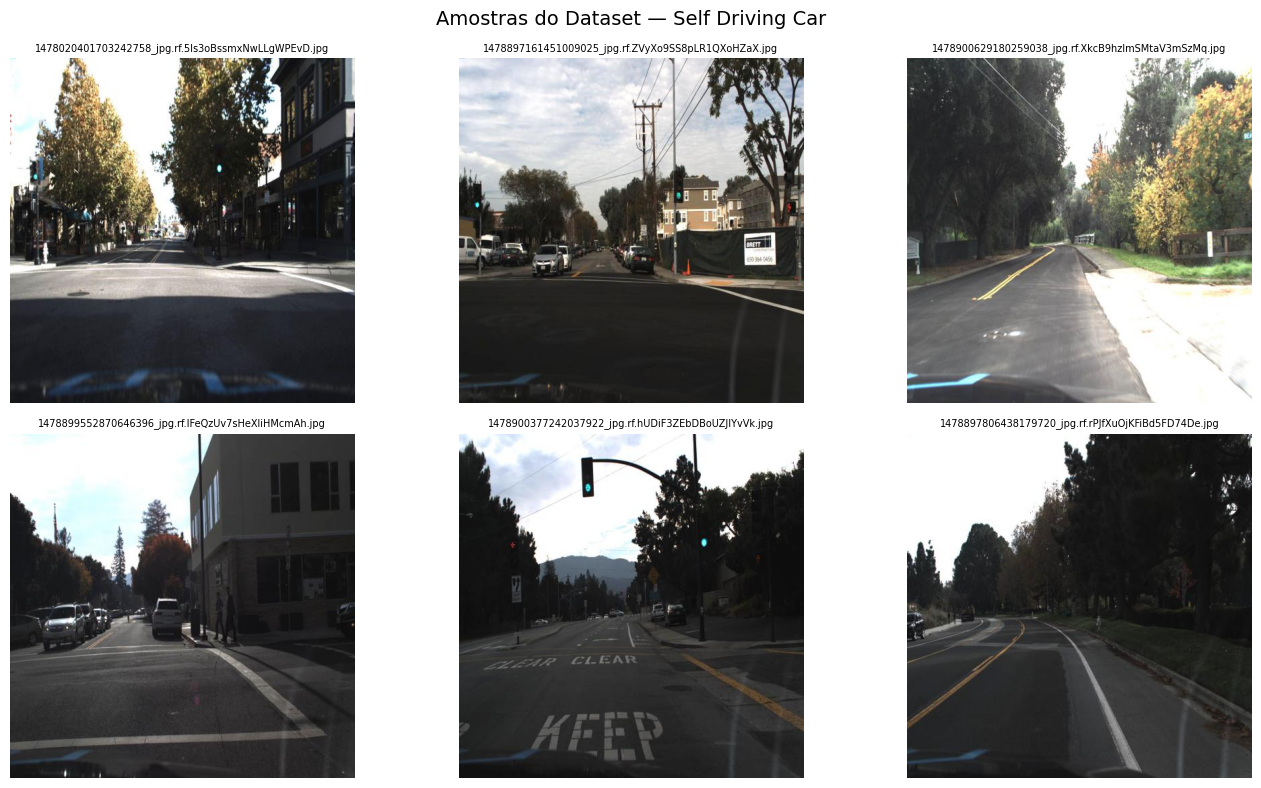

In [ ]:
# Visualizar amostras do dataset antes do treinamento
import glob
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_images = glob.glob(f"{dataset.location}/train/images/*.jpg")
sample = random.sample(train_images, min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Amostras do Dataset — Self Driving Car", fontsize=14)

for ax, img_path in zip(axes.flat, sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path), fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# Carregar o modelo pré-treinado — YOLOv26s
# YOLOv26s (Small): melhor precisão que o Nano, ainda adequado para tempo real
# Para máxima velocidade: yolo26n.pt | Para máxima precisão: yolo26m.pt
model = YOLO("yolo26s.pt")

print("Modelo carregado com sucesso!")
print(f"Parâmetros: {sum(p.numel() for p in model.model.parameters()):,}")

Modelo carregado com sucesso!
Parâmetros: 10,009,784


---
## **Treinando o Modelo**

In [ ]:
# Treinar / Transferência de conhecimento
!yolo task=detect mode=train \
    model=yolo26s.pt \
    data="/content/Self-Driving-Car-3/data.yaml" \
    epochs=15 \
    imgsz=640 \
    workers=2 \
    batch=10 \
    name=self_driving_car-3 \
    patience=5 \
    lr0=0.01 \
    mosaic=1.0

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Self-Driving-Car-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=self_driving_car-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

### 📌 Parâmetros de treinamento explicados

| Parâmetro | Valor | Descrição |
|-----------|-------|-----------|
| `epochs` | 15 | Número de passagens completas pelo dataset |
| `imgsz` | 640 | Resolução de entrada (padrão YOLO) |
| `batch` | 10 | Imagens por iteração |
| `patience` | 5 | Early stopping: para se não melhorar por 10 épocas |
| `lr0` | 0.01 | Learning rate inicial |
| `mosaic` | 1.0 | Augmentation que combina 4 imagens — muito útil para cenas de trânsito |
| `name` | self_driving_car | Pasta de saída em `runs/detect/` |



---
## **Avaliando o Modelo**

Curvas de treinamento:


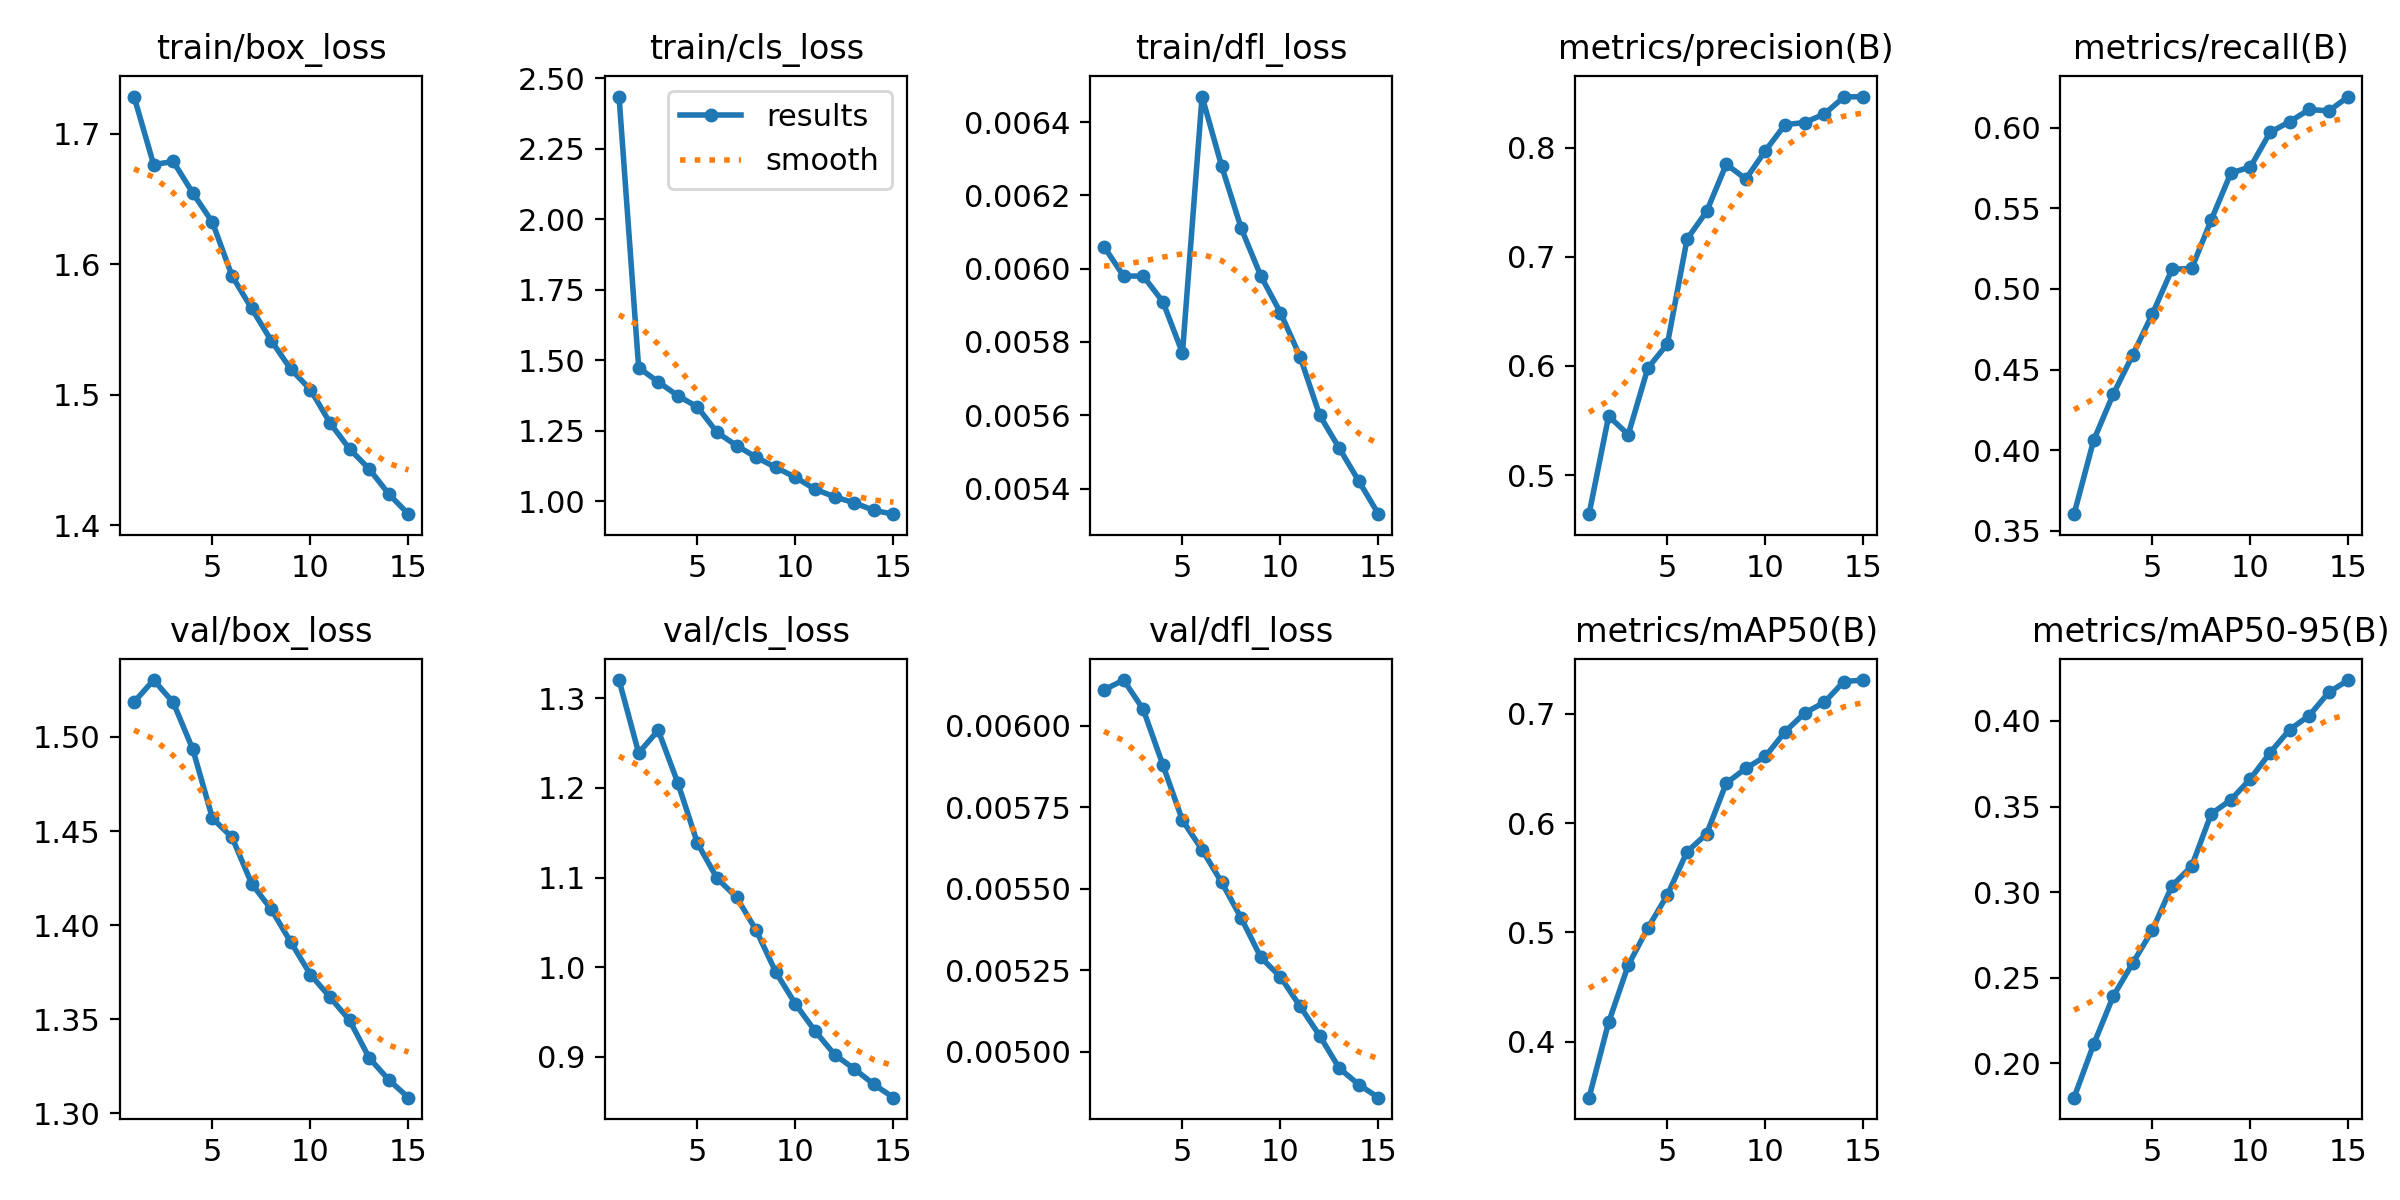

In [ ]:
# Visualizar curvas de treinamento (loss, mAP, precisão, recall)
from IPython.display import Image, display

results_path = "/content/runs/detect/self_driving_car-3"

results_img = f"{results_path}/results.png"
if os.path.exists(results_img):
    print("Curvas de treinamento:")
    display(Image(filename=results_img, width=900))


Matriz de confusão:


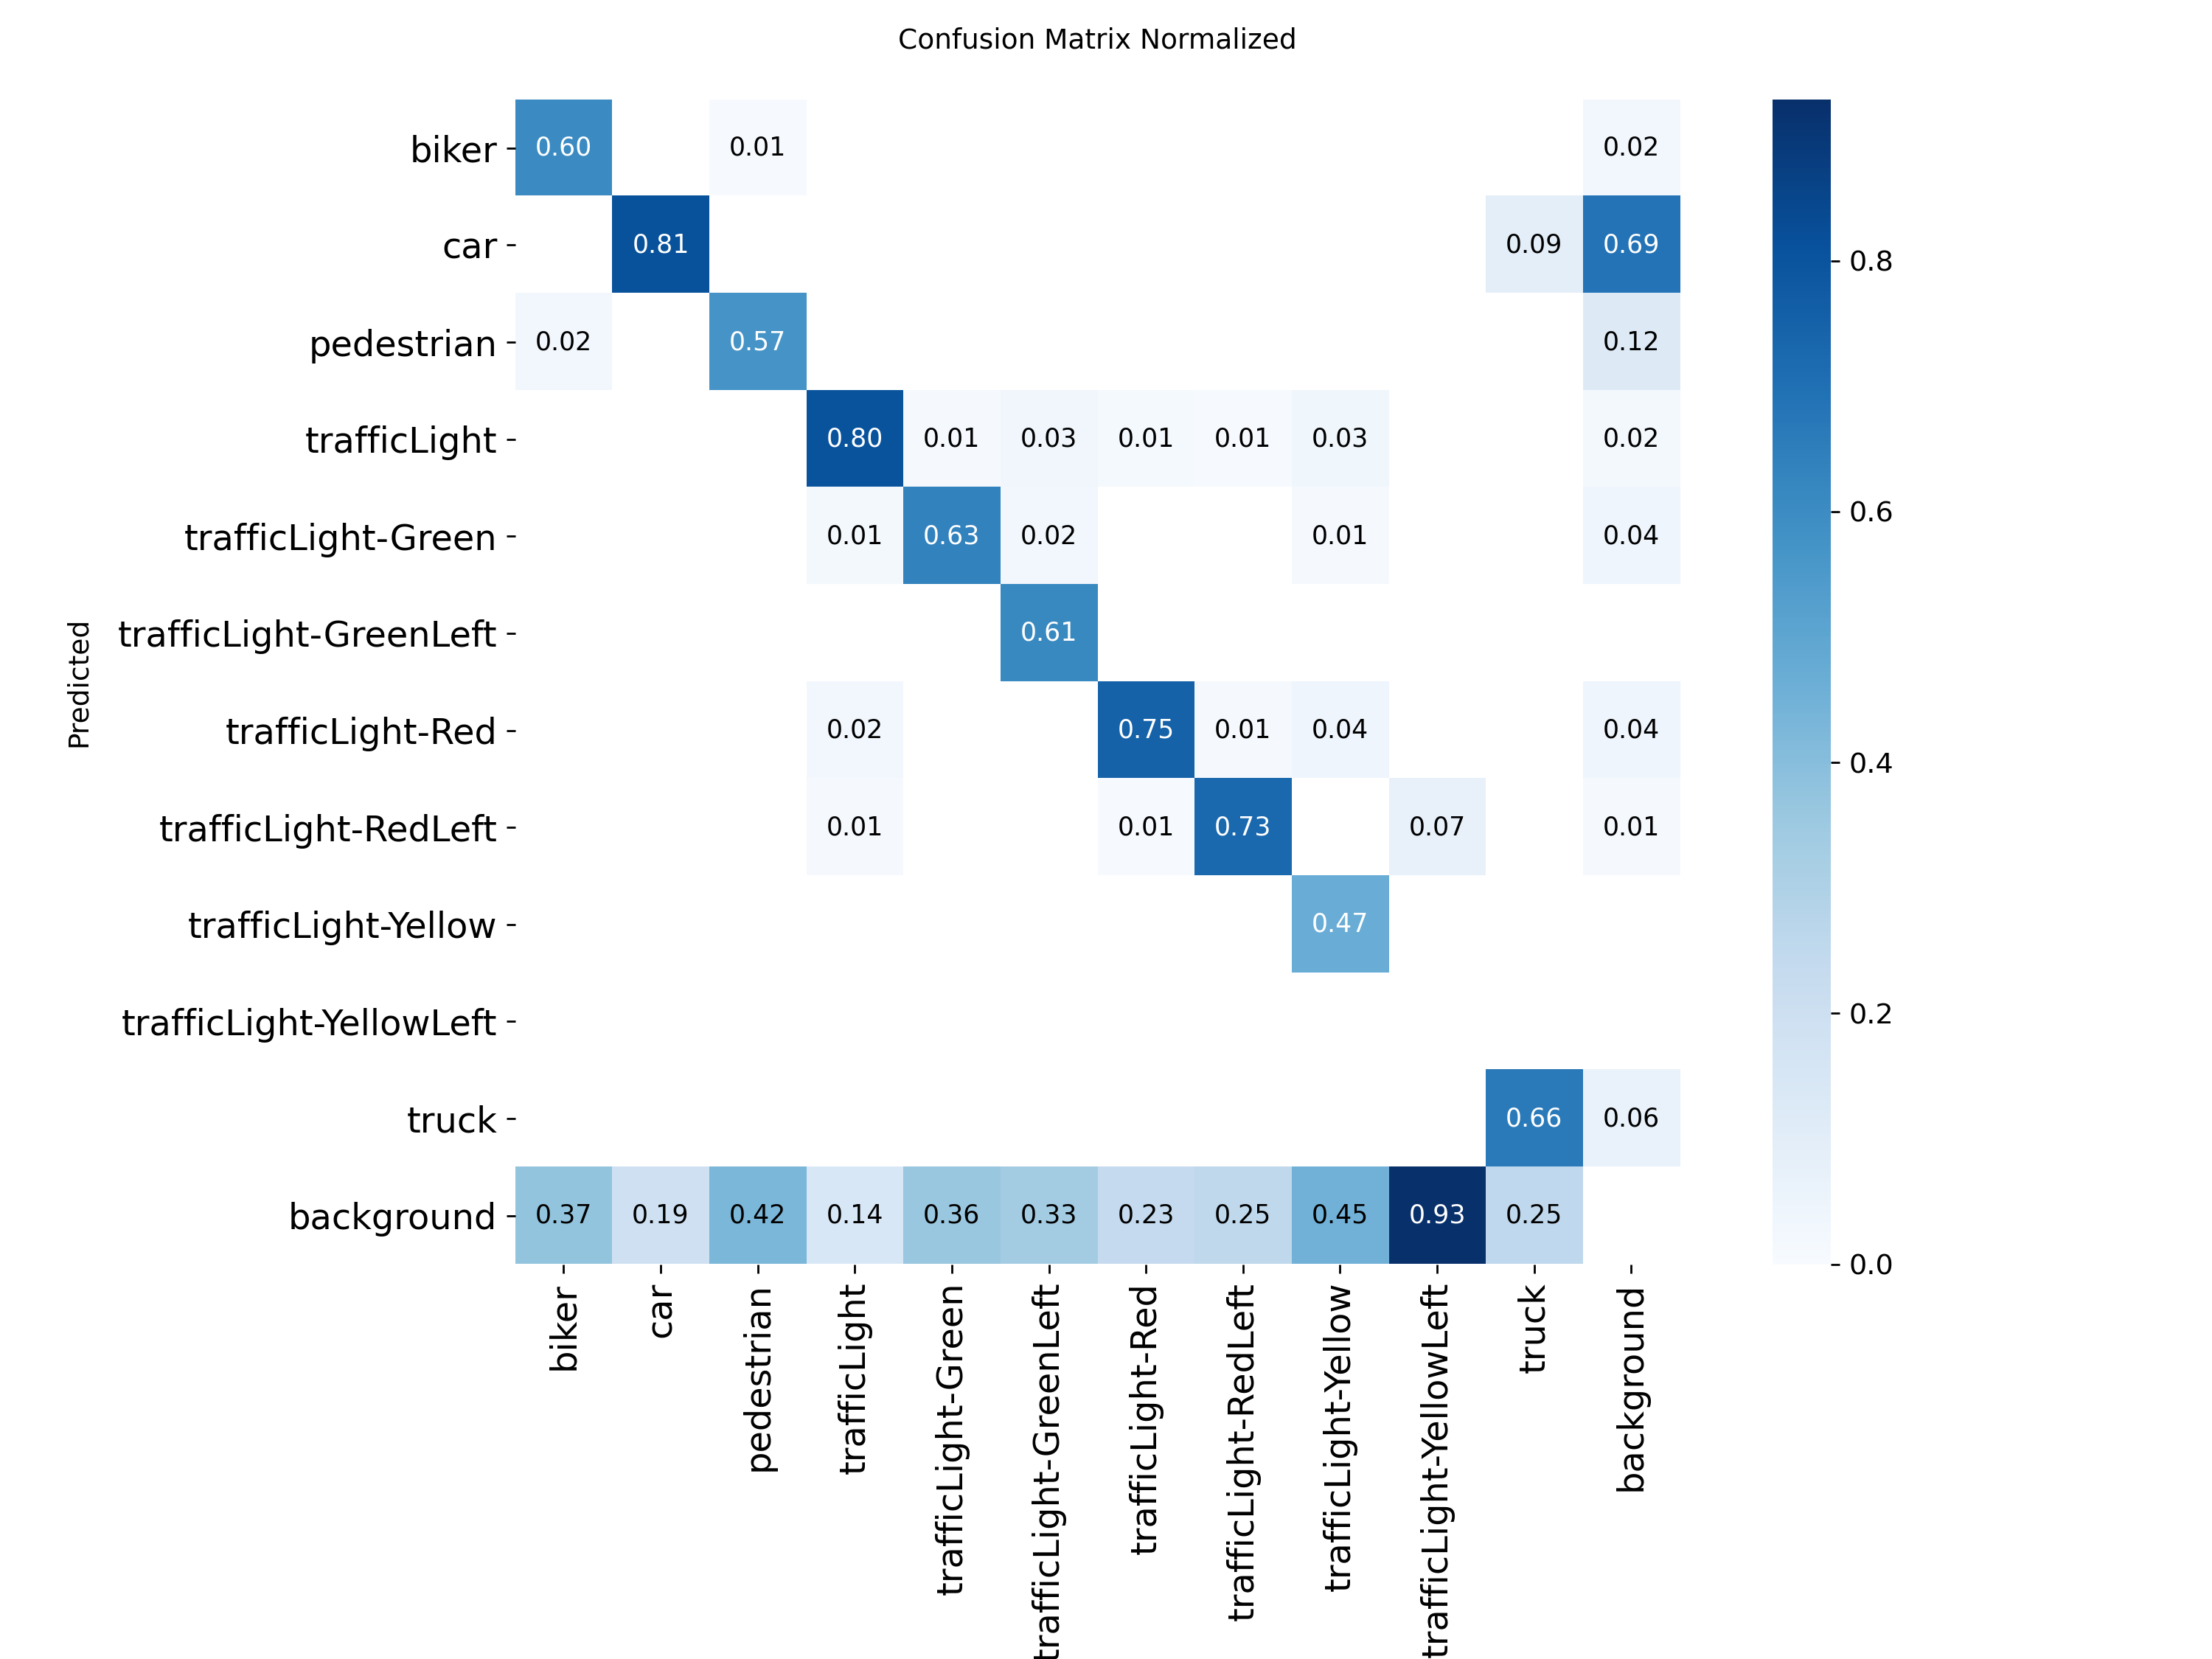

In [ ]:
# Matriz de confusão normalizada
conf_matrix = f"{results_path}/confusion_matrix_normalized.png"
if os.path.exists(conf_matrix):
    print("\nMatriz de confusão:")
    display(Image(filename=conf_matrix, width=700))

In [ ]:
# Validar o modelo gerado
best_model = YOLO("/content/runs/detect/self_driving_car-3/weights/best.pt")
metrics = best_model.val(data=f"{dataset.location}/data.yaml")

print("\n=== Métricas de Validação ===")
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precisão:   {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")

# mAP por classe
print("\n=== mAP50 por Classe ===")
class_names = data_config['names']
for i, (name, ap) in enumerate(zip(class_names, metrics.box.ap50)):
    print(f"  {name:<20} {ap:.4f}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,469,437 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1077.0±719.0 MB/s, size: 31.8 KB)
val: Scanning /content/Self-Driving-Car-3/train/labels.cache... 15000 images, 1761 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15000/15000 1.7Git/s 0.0s
train: /content/Self-Driving-Car-3/train/images/1478021875081281646_jpg.rf.bEZPhuyXU5hIovwQSTIp.jpg: 1 duplicate labels removed
train: /content/Self-Driving-Car-3/train/images/1478897760163798179_jpg.rf.5Pzrj3Eg3vZuyl7ztKAt.jpg: 1 duplicate labels removed
train: /content/Self-Driving-Car-3/train/images/1478898145212453716_jpg.rf.nCaFkPk4AFMjTQAM4RTJ.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 938/938 4.4it/s 3:35
                   all      15000      97939      0.848      0.619      0.731      0.

### 📊 Como interpretar as métricas para direção autônoma

Em sistemas de veículos autônomos, **Recall** é frequentemente mais importante que Precisão — é melhor detectar um falso positivo do que perder um pedestre real.

| Métrica | Referência | Significado |
|---------|-----------|-------------|
| mAP50 > 0.75 | Ótimo | Modelo pronto para testes em ambiente controlado |
| mAP50 0.55–0.75 | Bom | Funcional, mas com espaço para melhoria |
| mAP50 < 0.55 | Insuficiente | Necessita mais épocas ou dados adicionais |
| Recall (pedestres) | Deve ser > 0.85 | Classe mais crítica para segurança |

---
## **Inferência em Imagens**

In [ ]:
# Fazer inferência em imagens de teste
results = best_model.predict(
    source=f"{dataset.location}/test/images",
    conf=0.25,        # Limiar de confiança — baixo para não perder objetos críticos
    iou=0.45,         # NMS IoU threshold
    save=True,        # Salvar imagens anotadas
    save_conf=True,   # Mostrar score de confiança nas detecções
    save_txt=True,    # Salvar labels em formato YOLO (útil para análise posterior)
    name="inferencia_self_driving"
)

print(f"Inferência concluída em {len(results)} imagens.")
print(f"Imagens salvas em: /content/runs/detect/inferencia_self_driving/")


image 1/4 /content/Self-Driving-Car-3/test/images/Image4.jpg: 416x640 22 cars, 1 pedestrian, 1 trafficLight, 189024.0ms
image 2/4 /content/Self-Driving-Car-3/test/images/image.jpg: 448x640 1 biker, 8 cars, 2 pedestrians, 1 trafficLight-Red, 194367.6ms
image 3/4 /content/Self-Driving-Car-3/test/images/image2.jpg: 448x640 22 cars, 76306.9ms
image 4/4 /content/Self-Driving-Car-3/test/images/image3.jpeg: 448x640 9 cars, 1 pedestrian, 78129.2ms
Speed: 1230.0ms preprocess, 134456.9ms inference, 4278.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/inferencia_self_driving2
4 labels saved to /content/runs/detect/inferencia_self_driving2/labels
Inferência concluída em 4 imagens.
Imagens salvas em: /content/runs/detect/inferencia_self_driving/


In [ ]:
# Inferência em uma única imagem com análise detalhada das detecções
import glob
import random

test_images = glob.glob(f"/content/Self-Driving-Car-3/test/images/image2.jpg")
sample_img = random.choice(test_images)

result = best_model.predict(source=sample_img, conf=0.25, save=False)[0]

print(f"Imagem analisada: {os.path.basename(sample_img)}")
print(f"Objetos detectados: {len(result.boxes)}\n")

class_names = data_config['names']
for box in result.boxes:
    cls_id  = int(box.cls[0])
    conf    = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    print(f"  [{class_names[cls_id]:<18}] confiança: {conf:.2%}  bbox: ({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")


image 1/1 /content/Self-Driving-Car-3/test/images/image2.jpg: 448x640 22 cars, 82477.6ms
Speed: 2699.8ms preprocess, 82477.6ms inference, 4554.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/inferencia_self_driving2
4 labels saved to /content/runs/detect/inferencia_self_driving2/labels
Imagem analisada: image2.jpg
Objetos detectados: 22

  [car               ] confiança: 92.37%  bbox: (345, 415, 617, 562)
  [car               ] confiança: 91.36%  bbox: (237, 354, 410, 468)
  [car               ] confiança: 91.08%  bbox: (568, 331, 722, 444)
  [car               ] confiança: 90.66%  bbox: (80, 456, 388, 591)
  [car               ] confiança: 89.87%  bbox: (0, 396, 159, 519)
  [car               ] confiança: 88.73%  bbox: (772, 390, 886, 499)
  [car               ] confiança: 88.24%  bbox: (646, 277, 780, 348)
  [car               ] confiança: 87.20%  bbox: (771, 290, 878, 398)
  [car               ] confiança: 85.61%  bbox: (171, 284, 246, 351)

In [ ]:
# Exportar o modelo treinado

# ONNX — compatível com OpenCV DNN, TensorRT, ONNX Runtime (recomendado para deploy)
best_model.export(format="onnx")
print("Modelo exportado para ONNX!")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/self_driving_car-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...


In [ ]:
# Medir a velocidade de inferência do modelo (crítico para aplicações em tempo real)
import time
import glob

test_images = glob.glob(f"{dataset.location}/test/images/*.jpg")[:50]

start = time.time()
_ = best_model.predict(source=test_images, conf=0.25, verbose=False)
elapsed = time.time() - start

fps = len(test_images) / elapsed
ms_per_frame = (elapsed / len(test_images)) * 1000

print("=== Benchmark de Velocidade ===")
print(f"Imagens processadas : {len(test_images)}")
print(f"Tempo total         : {elapsed:.2f}s")
print(f"FPS médio           : {fps:.1f} frames/segundo")
print(f"Latência por frame  : {ms_per_frame:.1f} ms")
print()
if fps >= 30:
    print("Apto para uso em tempo real (>= 30 FPS)")
elif fps >= 15:
    print("Adequado para aplicações near-real-time (15–29 FPS)")
else:
    print("Latência alta — considere exportar para TensorRT ou usar hardware dedicado")

In [ ]:
# Fazer download dos pesos treinados para salvar localmente
from google.colab import files

# Download do melhor modelo (.pt)
files.download("/content/runs/detect/self_driving_car-3/weights/best.pt")

# Download do modelo ONNX
# files.download("/content/runs/detect/self_driving_car/weights/best.onnx")

print("Download iniciado!")

In [ ]:
# Download do último modelo (.pt)
files.download("/content/runs/detect/self_driving_car-3/weights/last.pt")

print("Download iniciado!")

---
# **🚀 Próximos passos**

Com o modelo treinado, você pode evoluir o projeto de diversas formas:

**Inferência em vídeo e câmera ao vivo**
```python
# Inferência em vídeo de trânsito
results = best_model.predict(source='video_transito.mp4', conf=0.25, save=True)

# Câmera ao vivo (webcam)
results = best_model.predict(source=0, conf=0.25, show=True)
```

**Estimativa de distância com câmera monocular**
```python
# Estimar distância aproximada pelo tamanho da bounding box
for box in result.boxes:
    area = (box.xyxy[0][2] - box.xyxy[0][0]) * (box.xyxy[0][3] - box.xyxy[0][1])
    dist_estimate = 50000 / float(area) ** 0.5  # fórmula empírica
    print(f"Distância estimada: {dist_estimate:.1f}m")
```

**Contagem de objetos por frame**
```python
from collections import Counter
contagem = Counter([class_names[int(b.cls[0])] for b in result.boxes])
print(dict(contagem))
```

**Deploy embarcado**
- *Raspberry Pi 4:* exporte para TFLite e use com `tflite-runtime`
- *NVIDIA Jetson Nano:* exporte para TensorRT (`.engine`) para máxima performance
- *Smartphone Android:* exporte para TFLite e integre via TensorFlow Lite Android SDK

**Melhorias no modelo**
- Adicione imagens de condições adversas (chuva, noite, neblina) ao dataset
- Use `augment=True` na predição para test-time augmentation
- Tente `yolo26m.pt` para ganhar ainda mais precisão se tiver GPU mais potente

---

---
*Projeto desenvolvido por <font color = #00a8ff>**Ana Clara Fortunato de Souza**</font>*

---